# 02 - Preprocess: segment, crop, cache, split

1. Segment every leaf from the white background (`src/masks.py`).
2. Crop to the leaf (5% margin) and cache crop + mask at 768 px long side in `ml/cache/`.
3. Check the masks visually.
4. Make stratified train / val / test splits for classes 0-4 and a holdout of class-5 leaves (`src/make_splits.py`).

In [1]:
import sys
from pathlib import Path

ML = Path.cwd()
while not (ML / "src").exists():
    ML = ML.parent
sys.path.insert(0, str(ML))

import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import CLASSES, CROPS, IMAGES, MASKS, ROOT
from src.make_splits import load_labels, make_splits
from src.masks import build_cache, read_rgb

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1-2. Build the crop cache

In [2]:
labels = load_labels()
t = time.time()
index = build_cache(labels["id"].tolist(), workers=8, overwrite=True)
index = index.merge(labels[["id", "label"]], on="id")
print(f"cached {len(index)} leaves in {time.time() - t:.0f}s")
print(f"leaf runs out of the photo frame: {index['leaf_cut_by_frame'].sum()}")
index["leaf_frac"].describe().round(3)

Premature end of JPEG file


cached 1402 leaves in 9s
leaf runs out of the photo frame: 109


count    1402.000
mean        0.332
std         0.063
min         0.107
25%         0.290
50%         0.331
75%         0.373
max         0.540
Name: leaf_frac, dtype: float64

## 3. Check the masks

`leaf_frac` is the share of the original photo covered by the leaf mask. Very small or very large values are the most likely segmentation failures, so those are shown first.

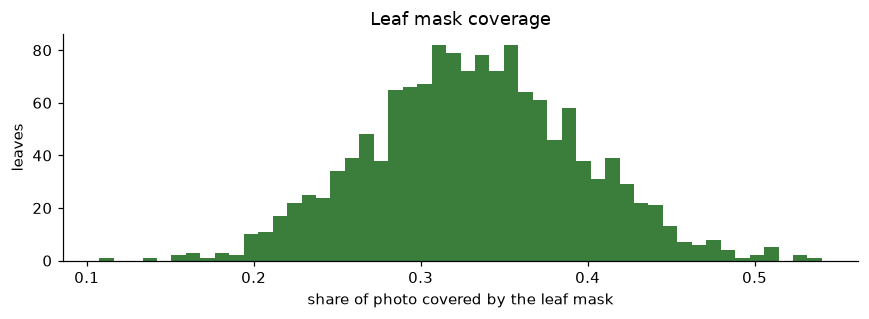

In [3]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(index["leaf_frac"], bins=50, color="#3b7d3b")
ax.set_xlabel("share of photo covered by the leaf mask")
ax.set_ylabel("leaves")
ax.set_title("Leaf mask coverage")
plt.tight_layout()

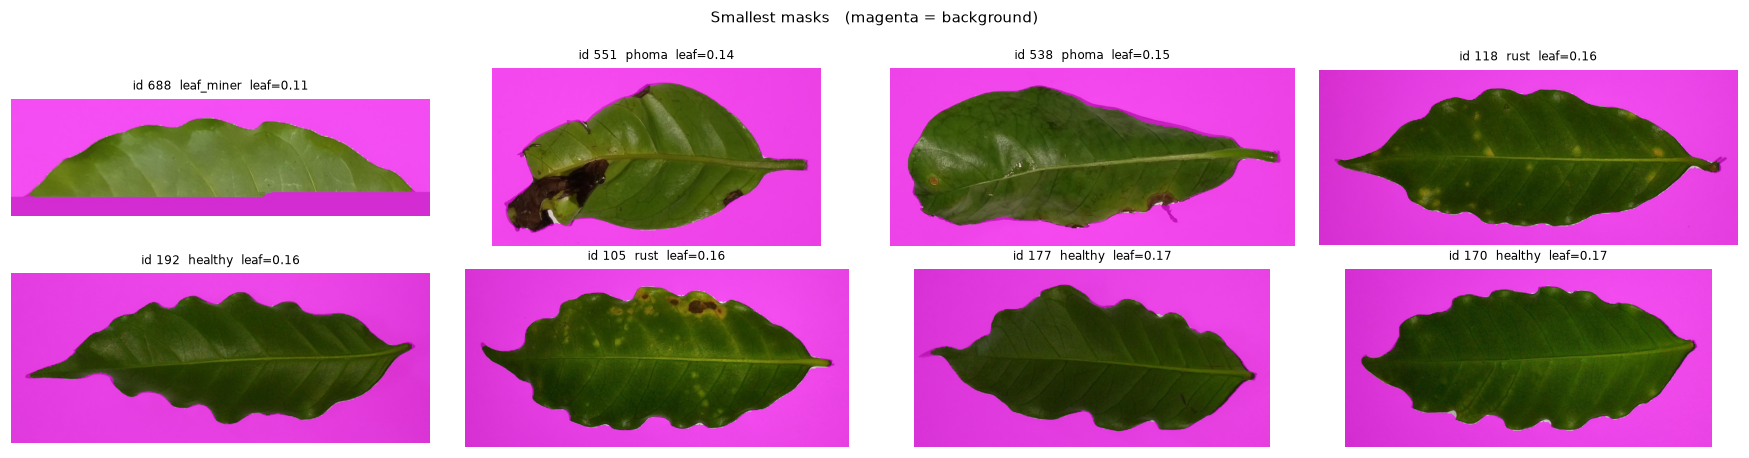

In [4]:
def overlay(image_id):
    crop = cv2.cvtColor(cv2.imread(str(CROPS / f"{image_id}.jpg")), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(MASKS / f"{image_id}.png"), cv2.IMREAD_GRAYSCALE)
    out = crop.copy()
    bg = mask == 0
    out[bg] = (0.35 * out[bg] + 0.65 * np.array([255, 0, 255])).astype(np.uint8)
    return out

def contact_sheet(rows, title, cols=4):
    n = len(rows)
    fig, axes = plt.subplots(int(np.ceil(n / cols)), cols, figsize=(4 * cols, 2.1 * np.ceil(n / cols)))
    for ax in axes.flat:
        ax.axis("off")
    for ax, (_, r) in zip(axes.flat, rows.iterrows()):
        ax.imshow(overlay(r["id"]))
        ax.set_title(f"id {r['id']}  {CLASSES[r['label']] if r['label'] < 5 else 'mixed'}  leaf={r['leaf_frac']:.2f}", fontsize=8)
    fig.suptitle(title + "   (magenta = background)", fontsize=10)
    plt.tight_layout()

contact_sheet(index.nsmallest(8, "leaf_frac"), "Smallest masks")

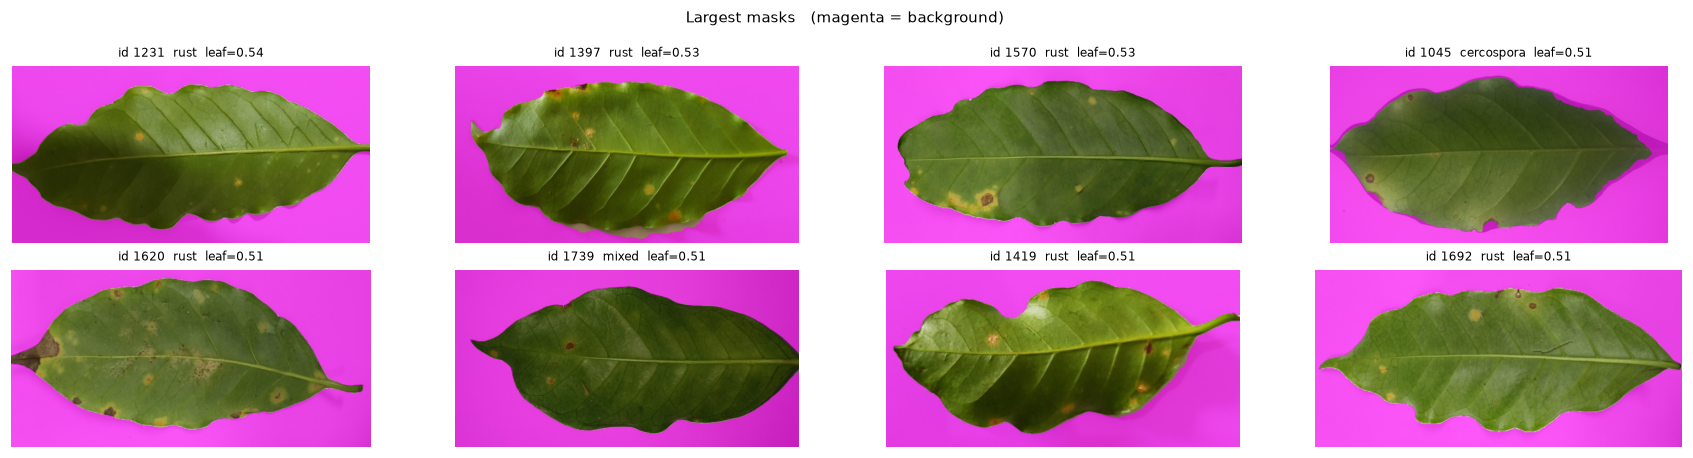

In [5]:
contact_sheet(index.nlargest(8, "leaf_frac"), "Largest masks")

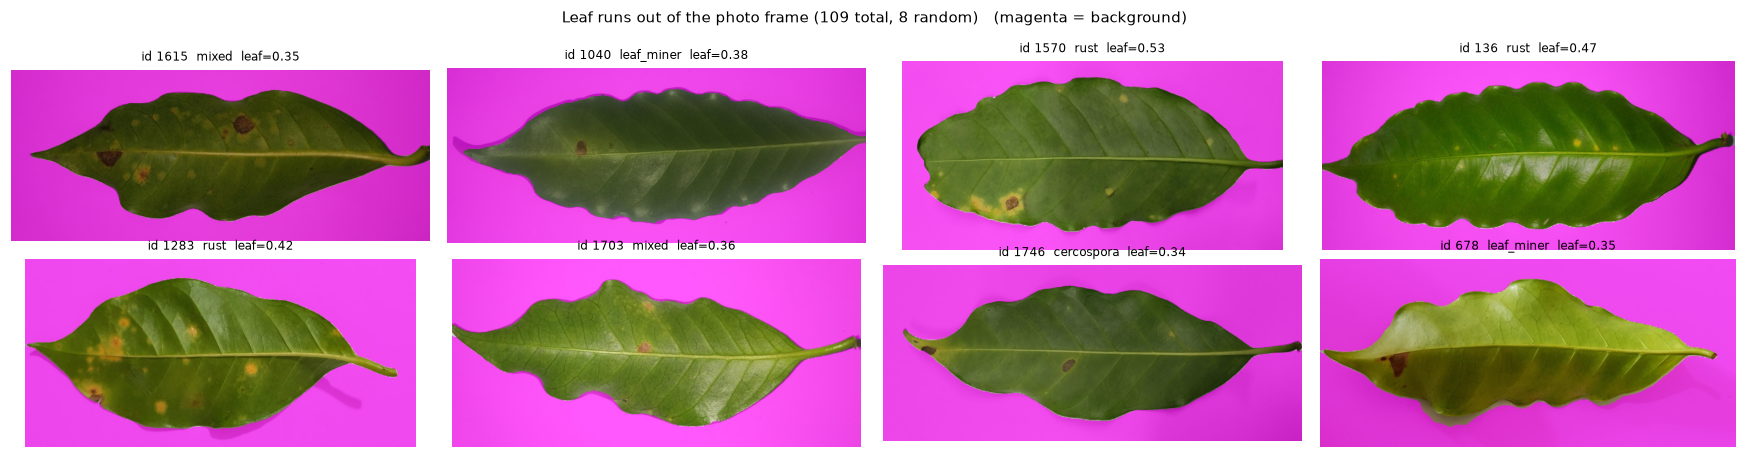

In [6]:
cut = index[index["leaf_cut_by_frame"]]
if len(cut):
    contact_sheet(cut.sample(min(8, len(cut)), random_state=0), f"Leaf runs out of the photo frame ({len(cut)} total, 8 random)")
else:
    print("every leaf is fully inside the photo")

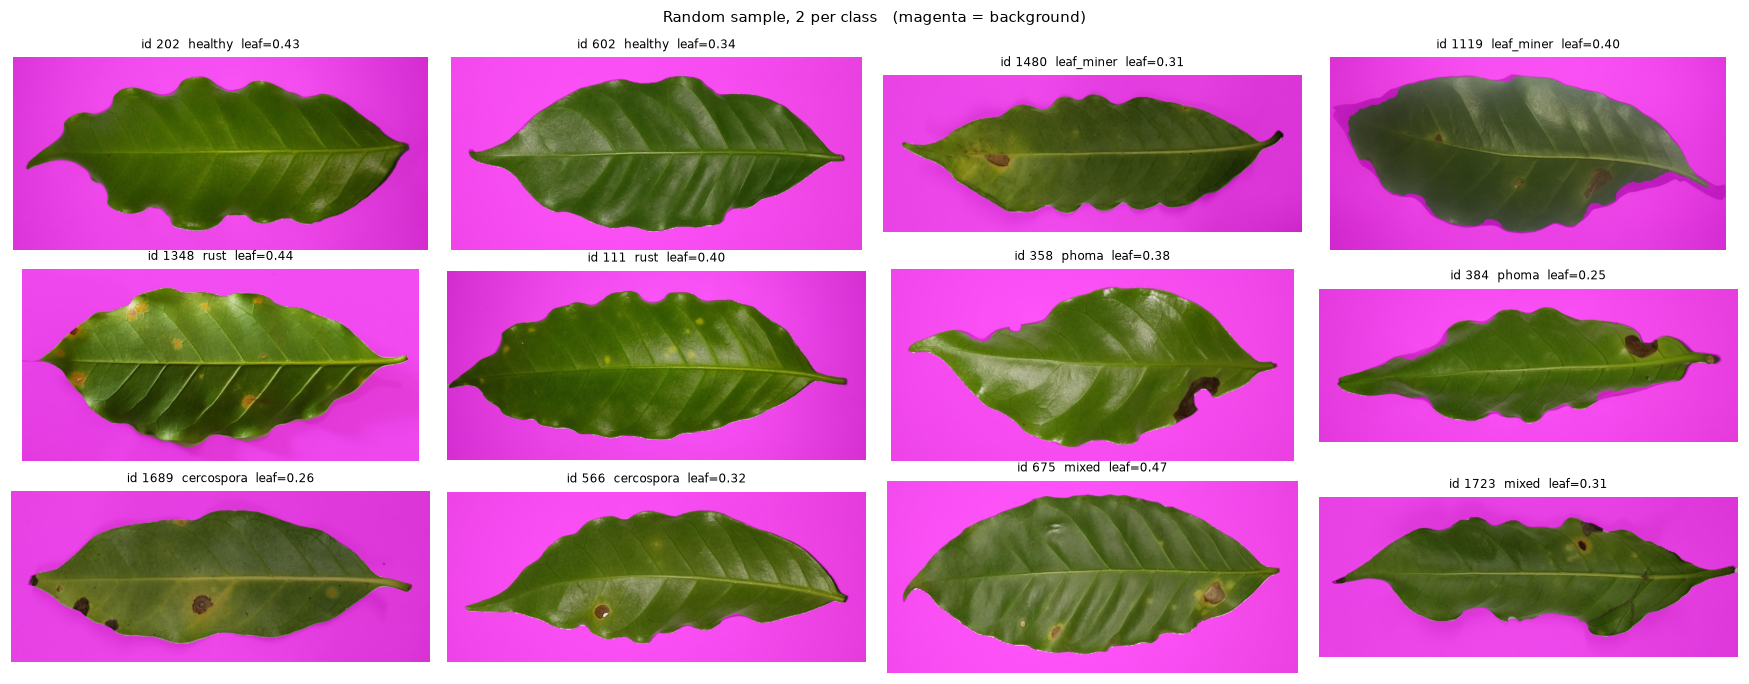

In [7]:
contact_sheet(index.groupby("label", group_keys=False).sample(2, random_state=0), "Random sample, 2 per class")

## 4. Splits

In [8]:
splits = make_splits()
counts = pd.DataFrame({
    name: part["label"].value_counts().reindex(range(5), fill_value=0)
    for name, part in splits.items() if name != "mixed_holdout"
})
counts.index = CLASSES
counts.loc["total"] = counts.sum()
print(f"mixed_holdout (class 5): {len(splits['mixed_holdout'])} leaves")
counts

mixed_holdout (class 5): 59 leaves


,train,val,test
healthy,99,21,22
leaf_miner,178,38,38
rust,326,69,70
phoma,242,52,52
cercospora,95,21,20
total,940,201,202


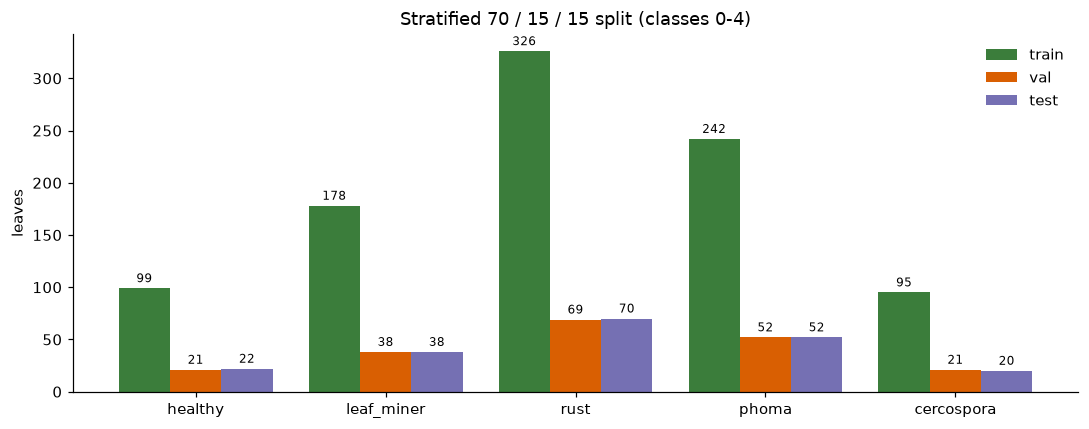

In [9]:
c = counts.drop("total")
x = np.arange(len(c))
fig, ax = plt.subplots(figsize=(10, 4))
for k, (name, color) in enumerate([("train", "#3b7d3b"), ("val", "#d95f02"), ("test", "#7570b3")]):
    bars = ax.bar(x + (k - 1) * 0.27, c[name], width=0.27, label=name, color=color)
    ax.bar_label(bars, padding=2, fontsize=8)
ax.set_xticks(x, c.index)
ax.set_ylabel("leaves")
ax.set_title("Stratified 70 / 15 / 15 split (classes 0-4)")
ax.legend(frameon=False)
plt.tight_layout()

In [10]:
ids = {name: set(part["id"]) for name, part in splits.items()}
assert not (ids["train"] & ids["val"]) and not (ids["train"] & ids["test"]) and not (ids["val"] & ids["test"])
assert all((ROOT / p).exists() for part in splits.values() for p in part["crop"])
print("splits are disjoint and every crop exists")

splits are disjoint and every crop exists
